# Quantization-Aware Training (QAT) — Clean Teaching Notebook

## Main idea

During QAT, the real trainable weights stay in **FP32**.

The forward pass simulates quantization:

$$
W_{FP32}\rightarrow q_{INT8}\rightarrow \hat W\rightarrow \text{Forward}\rightarrow \text{Loss}
$$

Then backpropagation updates the original FP32 weight:

$$
W_{FP32}\leftarrow W_{FP32}-\eta\frac{\partial L}{\partial W}
$$

$$
\boxed{\mathrm{INT8\ is\ not\ directly\ optimized}}
$$

This notebook has:
1. A single-weight example using `0.76`
2. A real MLP with QAT on the Digits dataset

---

**Colab note:** All equations in this notebook use `$...$` for inline math and `$$...$$` for display math so they render correctly in Google Colab.


In [1]:

import copy, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if "x86" in torch.backends.quantized.supported_engines:
    torch.backends.quantized.engine = "x86"
elif "fbgemm" in torch.backends.quantized.supported_engines:
    torch.backends.quantized.engine = "fbgemm"

print("PyTorch:", torch.__version__)
print("Quantized engine:", torch.backends.quantized.engine)


PyTorch: 2.10.0+cpu
Quantized engine: x86


# Part 1 — One Weight

Start with:

$$
w_{FP32}=0.76
$$

Choose:

$$
s=0.09125,\qquad z=0
$$

Then:

$$
q=\operatorname{round}(0.76/0.09125)=8
$$

and:

$$
\hat w=s(q-z)=0.73
$$

The forward pass uses `0.73`.  
The target is `0.82`, so training pushes the FP32 weight toward a region whose quantized code becomes `9`.

In [2]:

w = nn.Parameter(torch.tensor(0.76, dtype=torch.float32))

scale = 0.09125
zero_point = 0
qmin, qmax = -128, 127

x = torch.tensor(1.0)
target = torch.tensor(0.82)

optimizer = torch.optim.SGD([w], lr=0.10)

rows = []

for step in range(5):
    optimizer.zero_grad()

    # Forward: FP32 -> quantize -> dequantize
    w_fake = torch.fake_quantize_per_tensor_affine(
        w,
        scale=scale,
        zero_point=zero_point,
        quant_min=qmin,
        quant_max=qmax
    )

    prediction = x * w_fake
    loss = (prediction - target) ** 2

    q = torch.round(w.detach() / scale) + zero_point
    q = torch.clamp(q, qmin, qmax)

    rows.append({
        "Step": step,
        "FP32 Weight": float(w.detach()),
        "INT8 Code": int(q.item()),
        "Dequantized Weight": float(w_fake.detach()),
        "Loss": float(loss.detach())
    })

    # Backward: STE lets gradient pass through fake quantization
    loss.backward()

    # Only FP32 master weight is updated
    optimizer.step()

toy_history = pd.DataFrame(rows)
toy_history


,Step,FP32 Weight,INT8 Code,Dequantized Weight,Loss
0,0,0.76000,8,0.73000,0.008100
1,1,0.77800,9,0.82125,0.000002
2,2,0.77775,9,0.82125,0.000002
3,3,0.77750,9,0.82125,0.000002
4,4,0.77725,9,0.82125,0.000002


### Read the table like this

$$
0.76\rightarrow q=8\rightarrow 0.73\rightarrow Loss
$$

After backpropagation:

$$
0.76\rightarrow 0.778
$$

Then fake-quantize again:

$$
0.778\rightarrow q=9\rightarrow 0.82125
$$

The INT8 behavior changed **indirectly** because the FP32 weight changed.

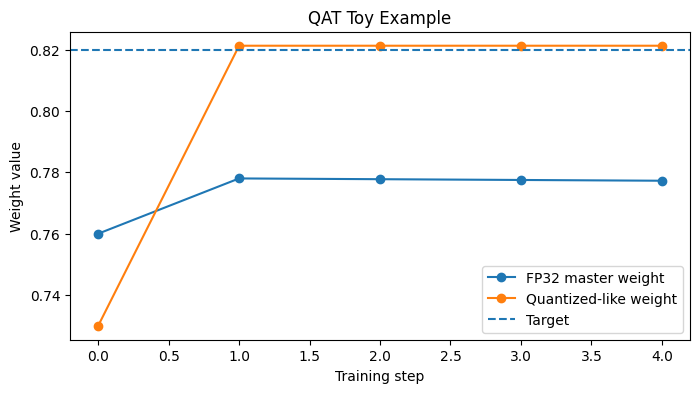

In [3]:

plt.figure(figsize=(8,4))
plt.plot(toy_history["Step"], toy_history["FP32 Weight"], marker="o", label="FP32 master weight")
plt.plot(toy_history["Step"], toy_history["Dequantized Weight"], marker="o", label="Quantized-like weight")
plt.axhline(float(target), linestyle="--", label="Target")
plt.xlabel("Training step")
plt.ylabel("Weight value")
plt.title("QAT Toy Example")
plt.legend()
plt.show()


# Part 2 — Real Neural Network

We use the built-in Digits dataset.

$$
64\rightarrow 32\rightarrow 10
$$

```text
Input
  ↓
QuantStub
  ↓
Linear(64,32)
  ↓
ReLU
  ↓
Linear(32,10)
  ↓
DeQuantStub
```

In [4]:

digits = load_digits()

X = digits.data.astype(np.float32) / 16.0
y = digits.target.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_ds = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

print("Train:", len(train_ds))
print("Test :", len(test_ds))


Train: 1437
Test : 360


In [5]:

class QuantizableMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.quant = torch.ao.quantization.QuantStub()
        self.fc1 = nn.Linear(64, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 10)
        self.dequant = torch.ao.quantization.DeQuantStub()

    def forward(self, x):
        x = self.quant(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.dequant(x)
        return x

fp32_model = QuantizableMLP()
fp32_model


QuantizableMLP(
  (quant): QuantStub()
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=10, bias=True)
  (dequant): DeQuantStub()
)

In [6]:

def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)

    return total_loss / total, correct / total


def train_fp32(model, epochs=8):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        model.train()

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        _, acc = evaluate(model, test_loader)
        print(f"FP32 Epoch {epoch:02d} | Accuracy: {acc:.4f}")

train_fp32(fp32_model)

_, fp32_accuracy = evaluate(fp32_model, test_loader)
print("\nFinal FP32 Accuracy:", round(fp32_accuracy, 4))


FP32 Epoch 01 | Accuracy: 0.4139
FP32 Epoch 02 | Accuracy: 0.6472
FP32 Epoch 03 | Accuracy: 0.7944
FP32 Epoch 04 | Accuracy: 0.8139
FP32 Epoch 05 | Accuracy: 0.8278
FP32 Epoch 06 | Accuracy: 0.8417
FP32 Epoch 07 | Accuracy: 0.8472
FP32 Epoch 08 | Accuracy: 0.8583

Final FP32 Accuracy: 0.8583


# Prepare for QAT

Use:

```python
default_qat_qconfig
```

This inserts real **FakeQuantize** modules for weights and activations.

In [7]:

qat_model = copy.deepcopy(fp32_model)
qat_model.train()

qat_model.qconfig = torch.ao.quantization.default_qat_qconfig

torch.ao.quantization.prepare_qat(qat_model, inplace=True)

print("Weight fake quant module:")
print(qat_model.fc1.weight_fake_quant)


Weight fake quant module:
FakeQuantize(
  fake_quant_enabled=tensor([1], dtype=torch.uint8), observer_enabled=tensor([1], dtype=torch.uint8), quant_min=-128, quant_max=127, dtype=torch.qint8, qscheme=torch.per_tensor_symmetric, ch_axis=-1, scale=tensor([1.]), zero_point=tensor([0], dtype=torch.int32)
  (activation_post_process): MovingAverageMinMaxObserver(min_val=inf, max_val=-inf)
)


# Track One Real Weight

For one weight we record:

$$
q=\operatorname{round}(w/s)+z
$$

$$
\hat w=s(q-z)
$$

We will print:
- FP32 weight
- INT8 code
- dequantized weight
- scale
- zero-point

In [8]:

# Initialize observer statistics
xb0, _ = next(iter(train_loader))
with torch.no_grad():
    _ = qat_model(xb0)

def snapshot(model, row=0, col=27):
    layer = model.fc1
    w = layer.weight.detach()
    w_fp32 = float(w[row, col])

    fq = layer.weight_fake_quant

    with torch.no_grad():
        w_fake = fq(w)

    w_dequant = float(w_fake[row, col])

    scale = float(fq.scale.flatten()[0])
    zero_point = int(fq.zero_point.flatten()[0])

    q = round(w_fp32 / scale) + zero_point
    q = int(max(fq.quant_min, min(fq.quant_max, q)))

    return {
        "FP32 Weight": w_fp32,
        "INT8 Code": q,
        "Dequantized Weight": w_dequant,
        "Scale": scale,
        "Zero Point": zero_point
    }

snapshot(qat_model)


{'FP32 Weight': -0.10086952149868011,
 'INT8 Code': -41,
 'Dequantized Weight': -0.10169296711683273,
 'Scale': 0.0024803162086755037,
 'Zero Point': 0}

# QAT Fine-Tuning

```text
FP32 master weight
      ↓
FakeQuantize
      ↓
Quantized-like forward pass
      ↓
Loss
      ↓
Backpropagation (STE)
      ↓
Update FP32 weight
      ↓
Repeat
```

In [9]:

def train_qat(model, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
    criterion = nn.CrossEntropyLoss()
    rows = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total = 0.0, 0

        for xb, yb in train_loader:
            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total += xb.size(0)

        s = snapshot(model)
        _, acc = evaluate(model, test_loader)

        rows.append({
            "Epoch": epoch,
            "Loss": total_loss / total,
            "FP32 Weight": s["FP32 Weight"],
            "INT8 Code": s["INT8 Code"],
            "Dequantized Weight": s["Dequantized Weight"],
            "Accuracy": acc
        })

        print(
            f"Epoch {epoch:02d} | "
            f"Loss={total_loss/total:.4f} | "
            f"FP32={s['FP32 Weight']:+.6f} | "
            f"q={s['INT8 Code']} | "
            f"Dequant={s['Dequantized Weight']:+.6f} | "
            f"Acc={acc:.4f}"
        )

    return pd.DataFrame(rows)

qat_history = train_qat(qat_model)
qat_history


Epoch 01 | Loss=0.8863 | FP32=-0.103980 | q=-42 | Dequant=-0.104173 | Acc=0.8528
Epoch 02 | Loss=0.8610 | FP32=-0.106597 | q=-43 | Dequant=-0.106654 | Acc=0.8556
Epoch 03 | Loss=0.8386 | FP32=-0.109147 | q=-44 | Dequant=-0.109134 | Acc=0.8556


Epoch 04 | Loss=0.8161 | FP32=-0.111645 | q=-45 | Dequant=-0.111770 | Acc=0.8583
Epoch 05 | Loss=0.7949 | FP32=-0.114130 | q=-46 | Dequant=-0.114595 | Acc=0.8583


,Epoch,Loss,FP32 Weight,INT8 Code,Dequantized Weight,Accuracy
0,1,0.886319,-0.103980,-42,-0.104173,0.852778
1,2,0.861014,-0.106597,-43,-0.106654,0.855556
2,3,0.838634,-0.109147,-44,-0.109134,0.855556
3,4,0.816149,-0.111645,-45,-0.111770,0.858333
4,5,0.794887,-0.114130,-46,-0.114595,0.858333


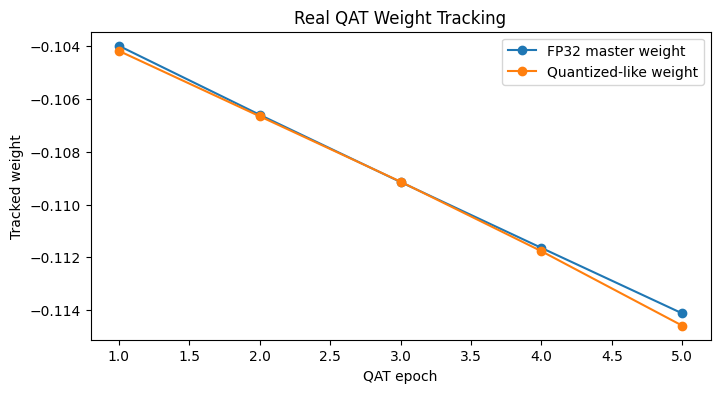

In [10]:

plt.figure(figsize=(8,4))
plt.plot(qat_history["Epoch"], qat_history["FP32 Weight"], marker="o", label="FP32 master weight")
plt.plot(qat_history["Epoch"], qat_history["Dequantized Weight"], marker="o", label="Quantized-like weight")
plt.xlabel("QAT epoch")
plt.ylabel("Tracked weight")
plt.title("Real QAT Weight Tracking")
plt.legend()
plt.show()


# Convert to a Real INT8 Model

During QAT:

$$
\text{FP32 weights + FakeQuantize}
$$

After training:

$$
\text{convert()}
\rightarrow
\text{real quantized operators}
$$

In [11]:

qat_model.eval()

int8_model = copy.deepcopy(qat_model)

int8_model = torch.ao.quantization.convert(
    int8_model,
    inplace=False
)

print(int8_model)


QuantizableMLP(
  (quant): Quantize(scale=tensor([0.0079]), zero_point=tensor([0]), dtype=torch.quint8)
  (fc1): QuantizedLinear(in_features=64, out_features=32, scale=0.031185662373900414, zero_point=38, qscheme=torch.per_tensor_affine)
  (relu): ReLU()
  (fc2): QuantizedLinear(in_features=32, out_features=10, scale=0.05744299665093422, zero_point=74, qscheme=torch.per_tensor_affine)
  (dequant): DeQuantize()
)


In [12]:

_, int8_accuracy = evaluate(int8_model, test_loader)

print("FP32 Accuracy:", round(fp32_accuracy, 4))
print("INT8 Accuracy :", round(int8_accuracy, 4))

print("\nActual integer weights from fc1:")
print(torch.int_repr(int8_model.fc1.weight())[:5, :8])


FP32 Accuracy: 0.8583
INT8 Accuracy : 0.8583

Actual integer weights from fc1:
tensor([[ 38,  97,  -9,  71,  22,  -7, -27,  59],
        [ 15, -10,  42, -30, -30, -30,  45,  17],
        [ 42,  12,  57,   8, -59,  46, -25, -58],
        [ 32,  -5, -67, -41,  32, -35, -53, -13],
        [ 28,  39, 101,  48,  61,  16,  42, -85]], dtype=torch.int8)


# Final Summary

## During QAT

$$
W_{FP32}
\rightarrow
FakeQuant
\rightarrow
\hat W
\rightarrow
Prediction
\rightarrow
Loss
$$

Then:

$$
Loss
\rightarrow
STE
\rightarrow
\text{Update }W_{FP32}
$$

Then fake-quantize the new FP32 weight again.

$$
\boxed{\mathrm{INT8\ is\ not\ directly\ trained}}
$$

$$
\boxed{\mathrm{FP32\ learns\ for\ low\ quantized\ loss}}
$$

After training:

$$
\boxed{\mathrm{QAT\ model}\rightarrow\mathrm{Convert}\rightarrow\mathrm{INT8\ model}}
$$